# Análise de Dados e Modelo Preditivo: Preço de Carros

https://www.kaggle.com/datasets/asinow/car-price-dataset

## Carregamento dos Dados

In [ ]:
#Importando bibliotecas necessarias
import os
import shap
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import entropy
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report # Added classification_report import here
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score

In [ ]:
#Carregando os dados
path = kagglehub.dataset_download("asinow/car-price-dataset")
csv_path = os.path.join(path,"car_price_dataset.csv")

dados = pd.read_csv(csv_path)

In [ ]:
#Verificar valores ausentes
print(dados.isnull().sum())

dados.info()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  int64  
 1   Model         10000 non-null  int64  
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  int64  
 5   Transmission  10000 non-null  int64  
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


In [ ]:
#Primeira linhas dos dados
dados.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


## Análise de Distribuições

In [ ]:
#@markdown #### .
var_numerica = ['Mileage','Price']
var_categorica = dados.columns.difference(var_numerica)

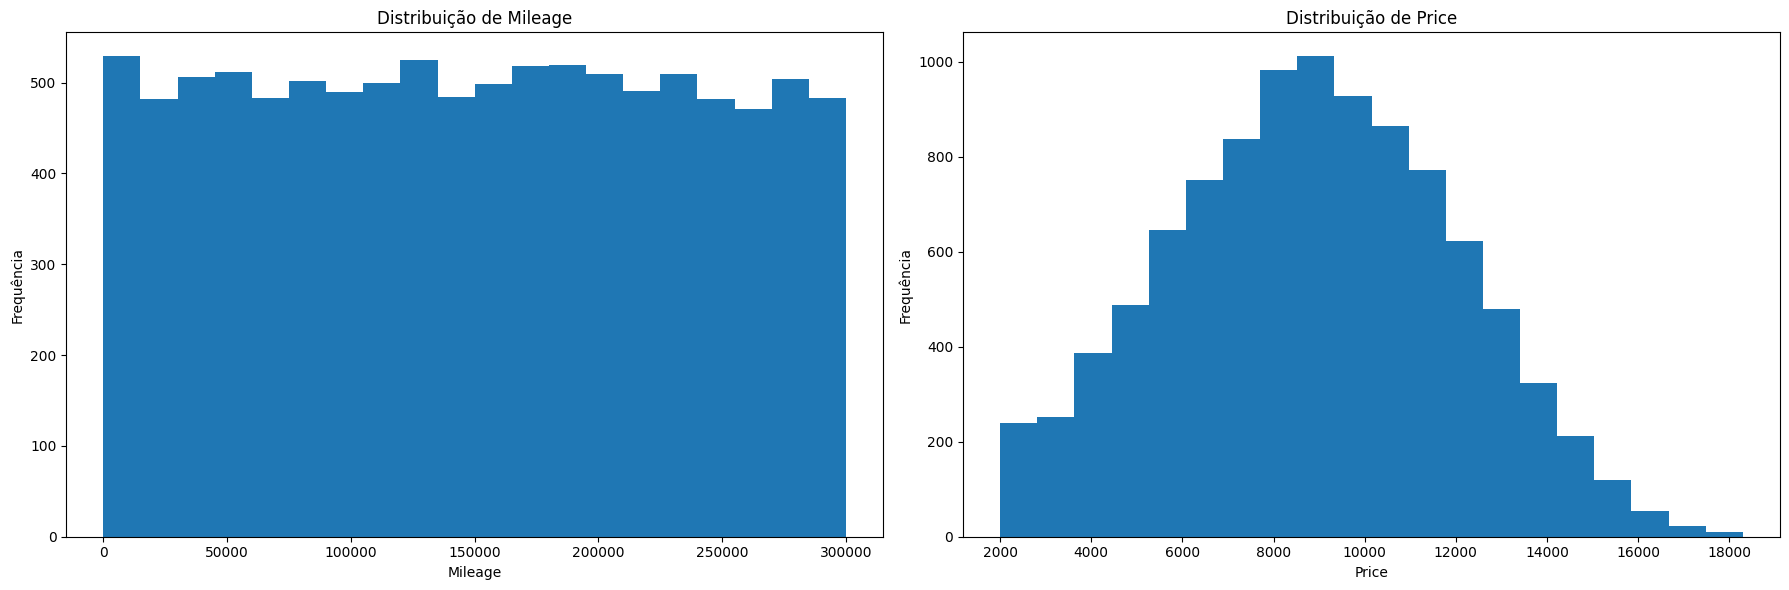

In [ ]:
#Plotar distribuições das variaveis numericas
fig,axes = plt.subplots(1,2,figsize=(18,6))

for i, coluna in enumerate(var_numerica):
    linha = i // 2
    col = i % 2
    ax = axes[i]

    ax.hist(dados[coluna], bins=20)
    ax.set_title(f'Distribuição de {coluna}')
    ax.set_xlabel(coluna)
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

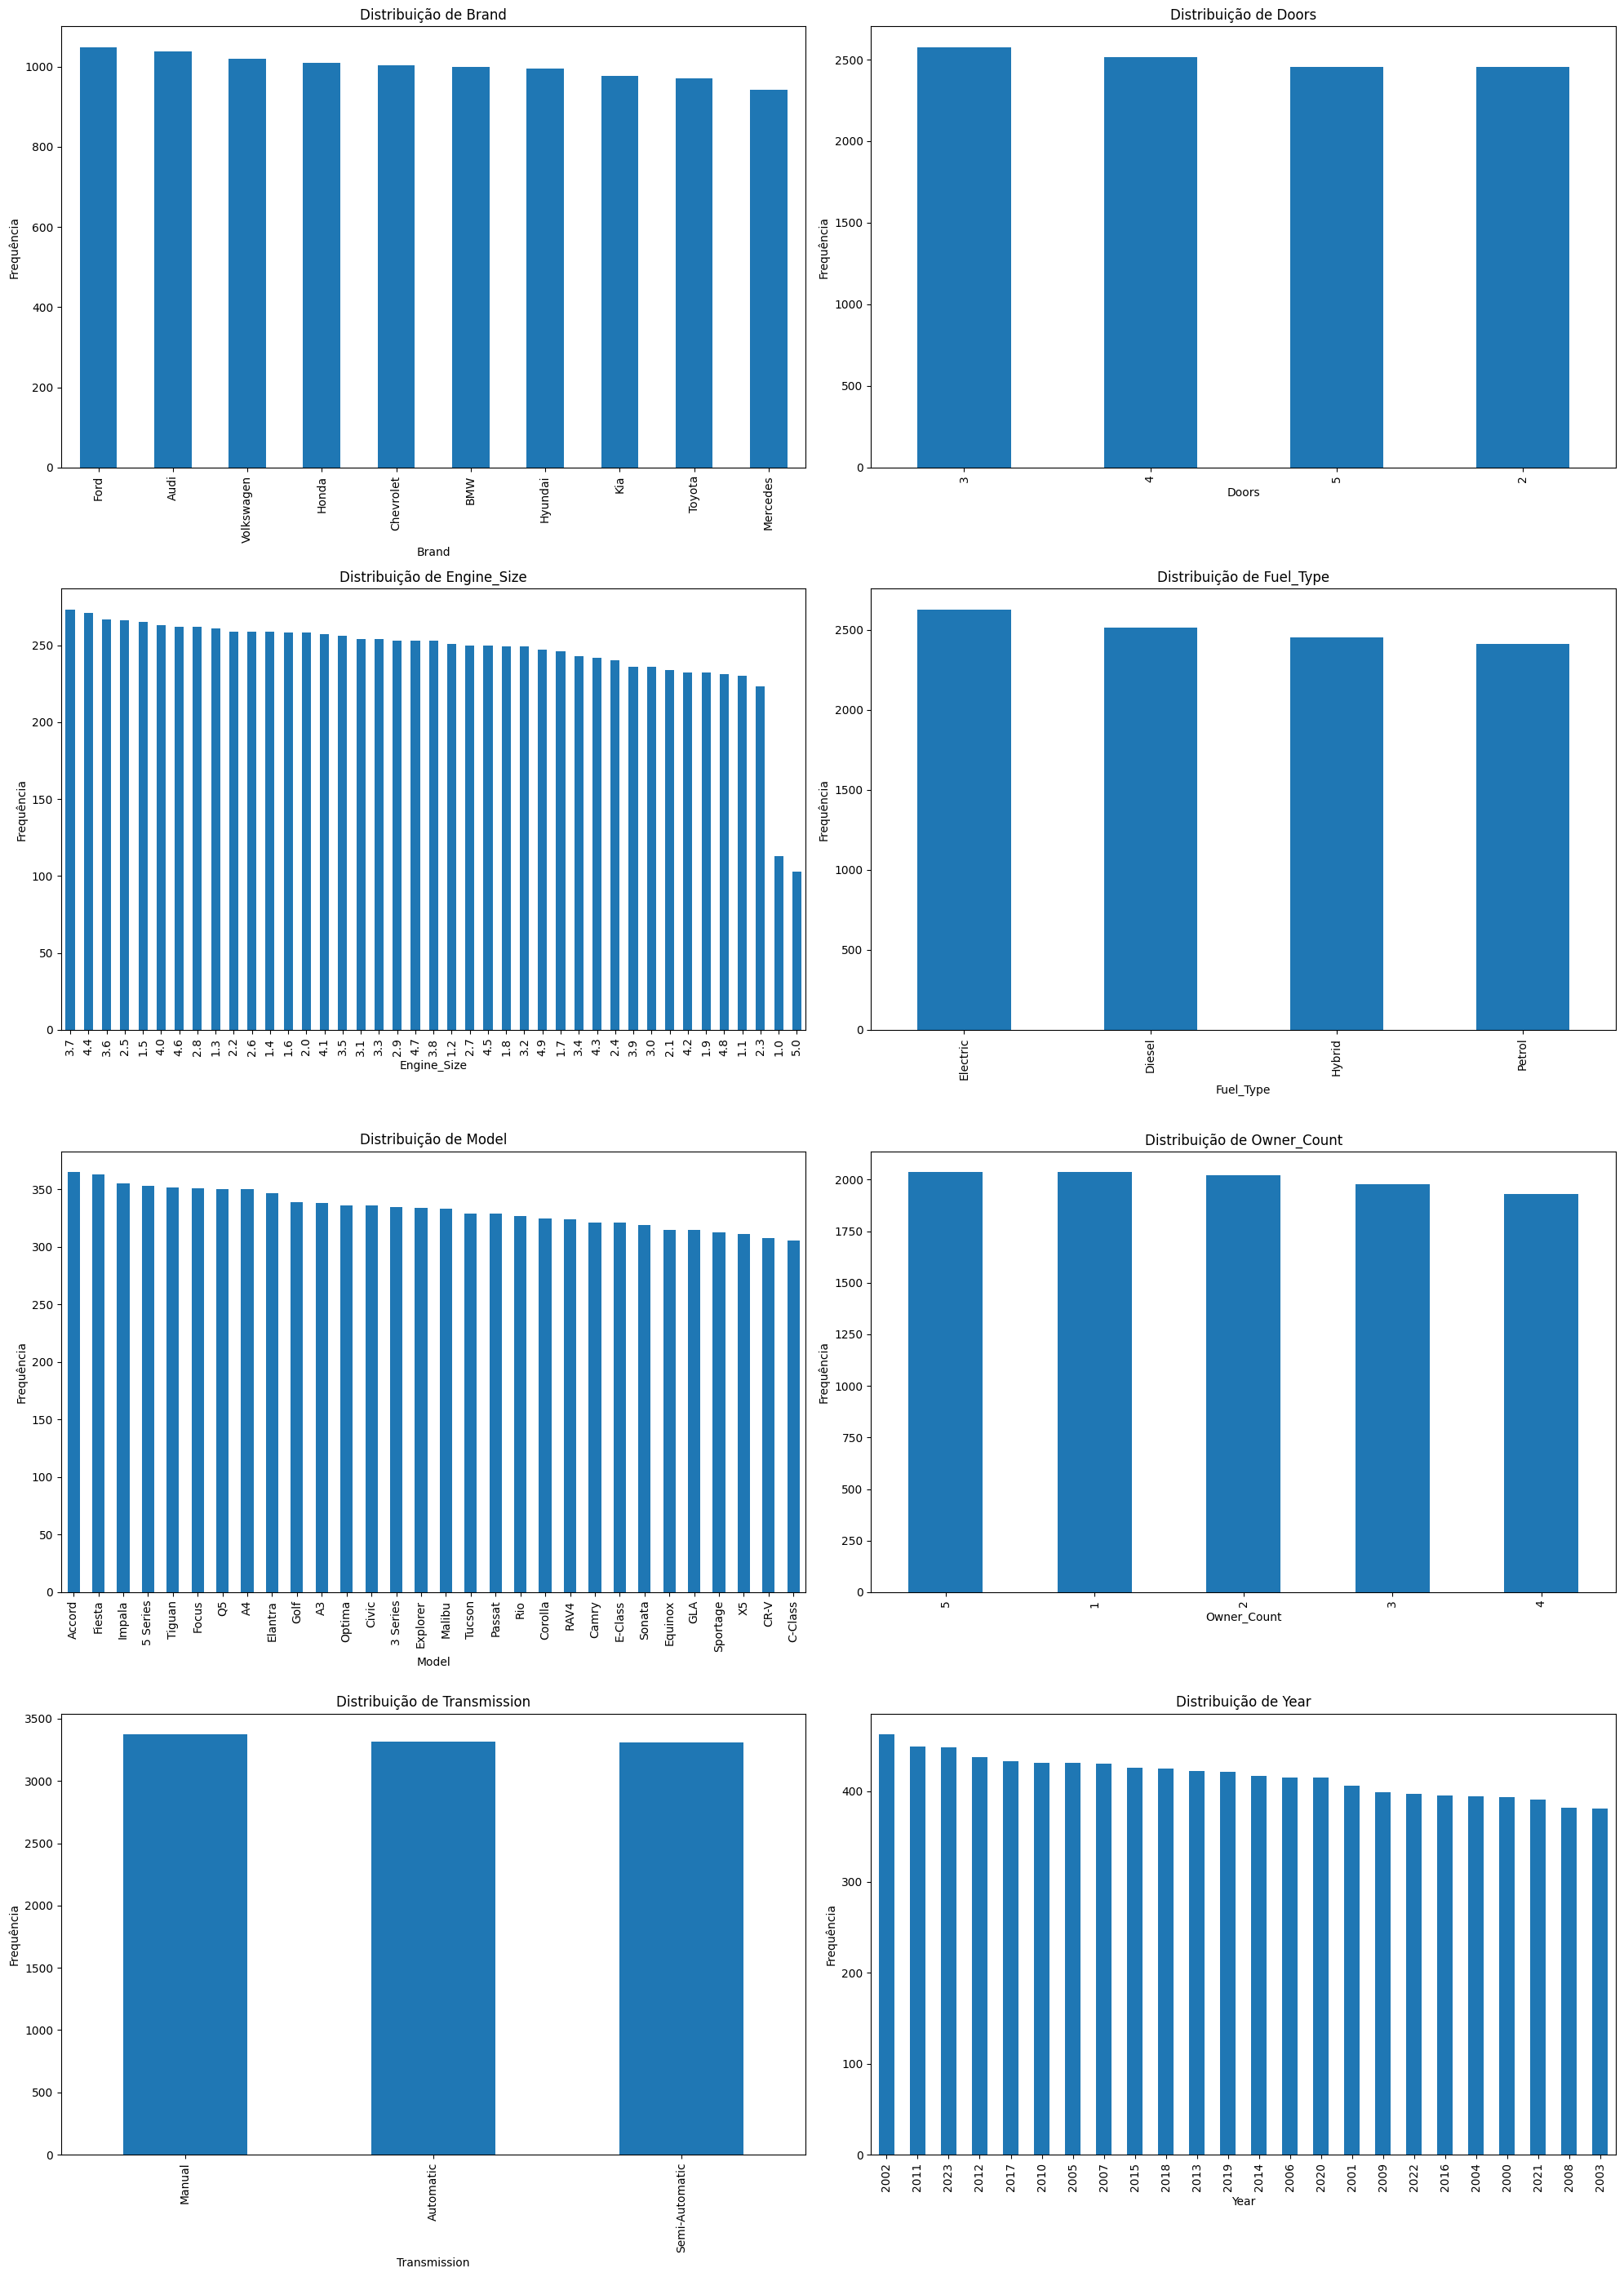

In [ ]:
#Plotar distribuições categoricas
fig,axes = plt.subplots(4,2,figsize=(20,28))

for i, coluna in enumerate(var_categorica):
    linha = i // 2
    col = i % 2
    ax = axes[linha,col]

    dados[coluna].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'Distribuição de {coluna}')
    ax.set_xlabel(coluna)
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

## Análise Exploratoria

In [ ]:
#@markdown #### .
df_anos_precos = dados.groupby(['Year'])['Price'].mean().reset_index()
df_anos_precos['MoM%'] = df_anos_precos['Price'].pct_change() * 100

df_variacao_marca_preco = dados.groupby(['Brand','Year'])['Price'].mean().reset_index()
df_variacao_marca_preco = df_variacao_marca_preco.sort_values(by=['Brand','Year'])
df_variacao_marca_preco['MoM%'] = df_variacao_marca_preco.groupby('Brand')['Price'].pct_change() * 100
df_variacao_marca_preco = df_variacao_marca_preco.groupby('Brand')['MoM%'].sum().reset_index()

df_top_5_marcas = df_variacao_marca_preco.nlargest(5, 'MoM%')

df_variacao_modelo_preco = dados.groupby(['Model','Year'])['Price'].mean().reset_index()
df_variacao_modelo_preco = df_variacao_modelo_preco.sort_values(by=['Model','Year'])
df_variacao_modelo_preco['MoM%'] = df_variacao_modelo_preco.groupby('Model')['Price'].pct_change() * 100
df_variacao_modelo_preco = df_variacao_modelo_preco.groupby('Model')['MoM%'].sum().reset_index()

df_top_5_modelo = df_variacao_modelo_preco.nlargest(5, 'MoM%')

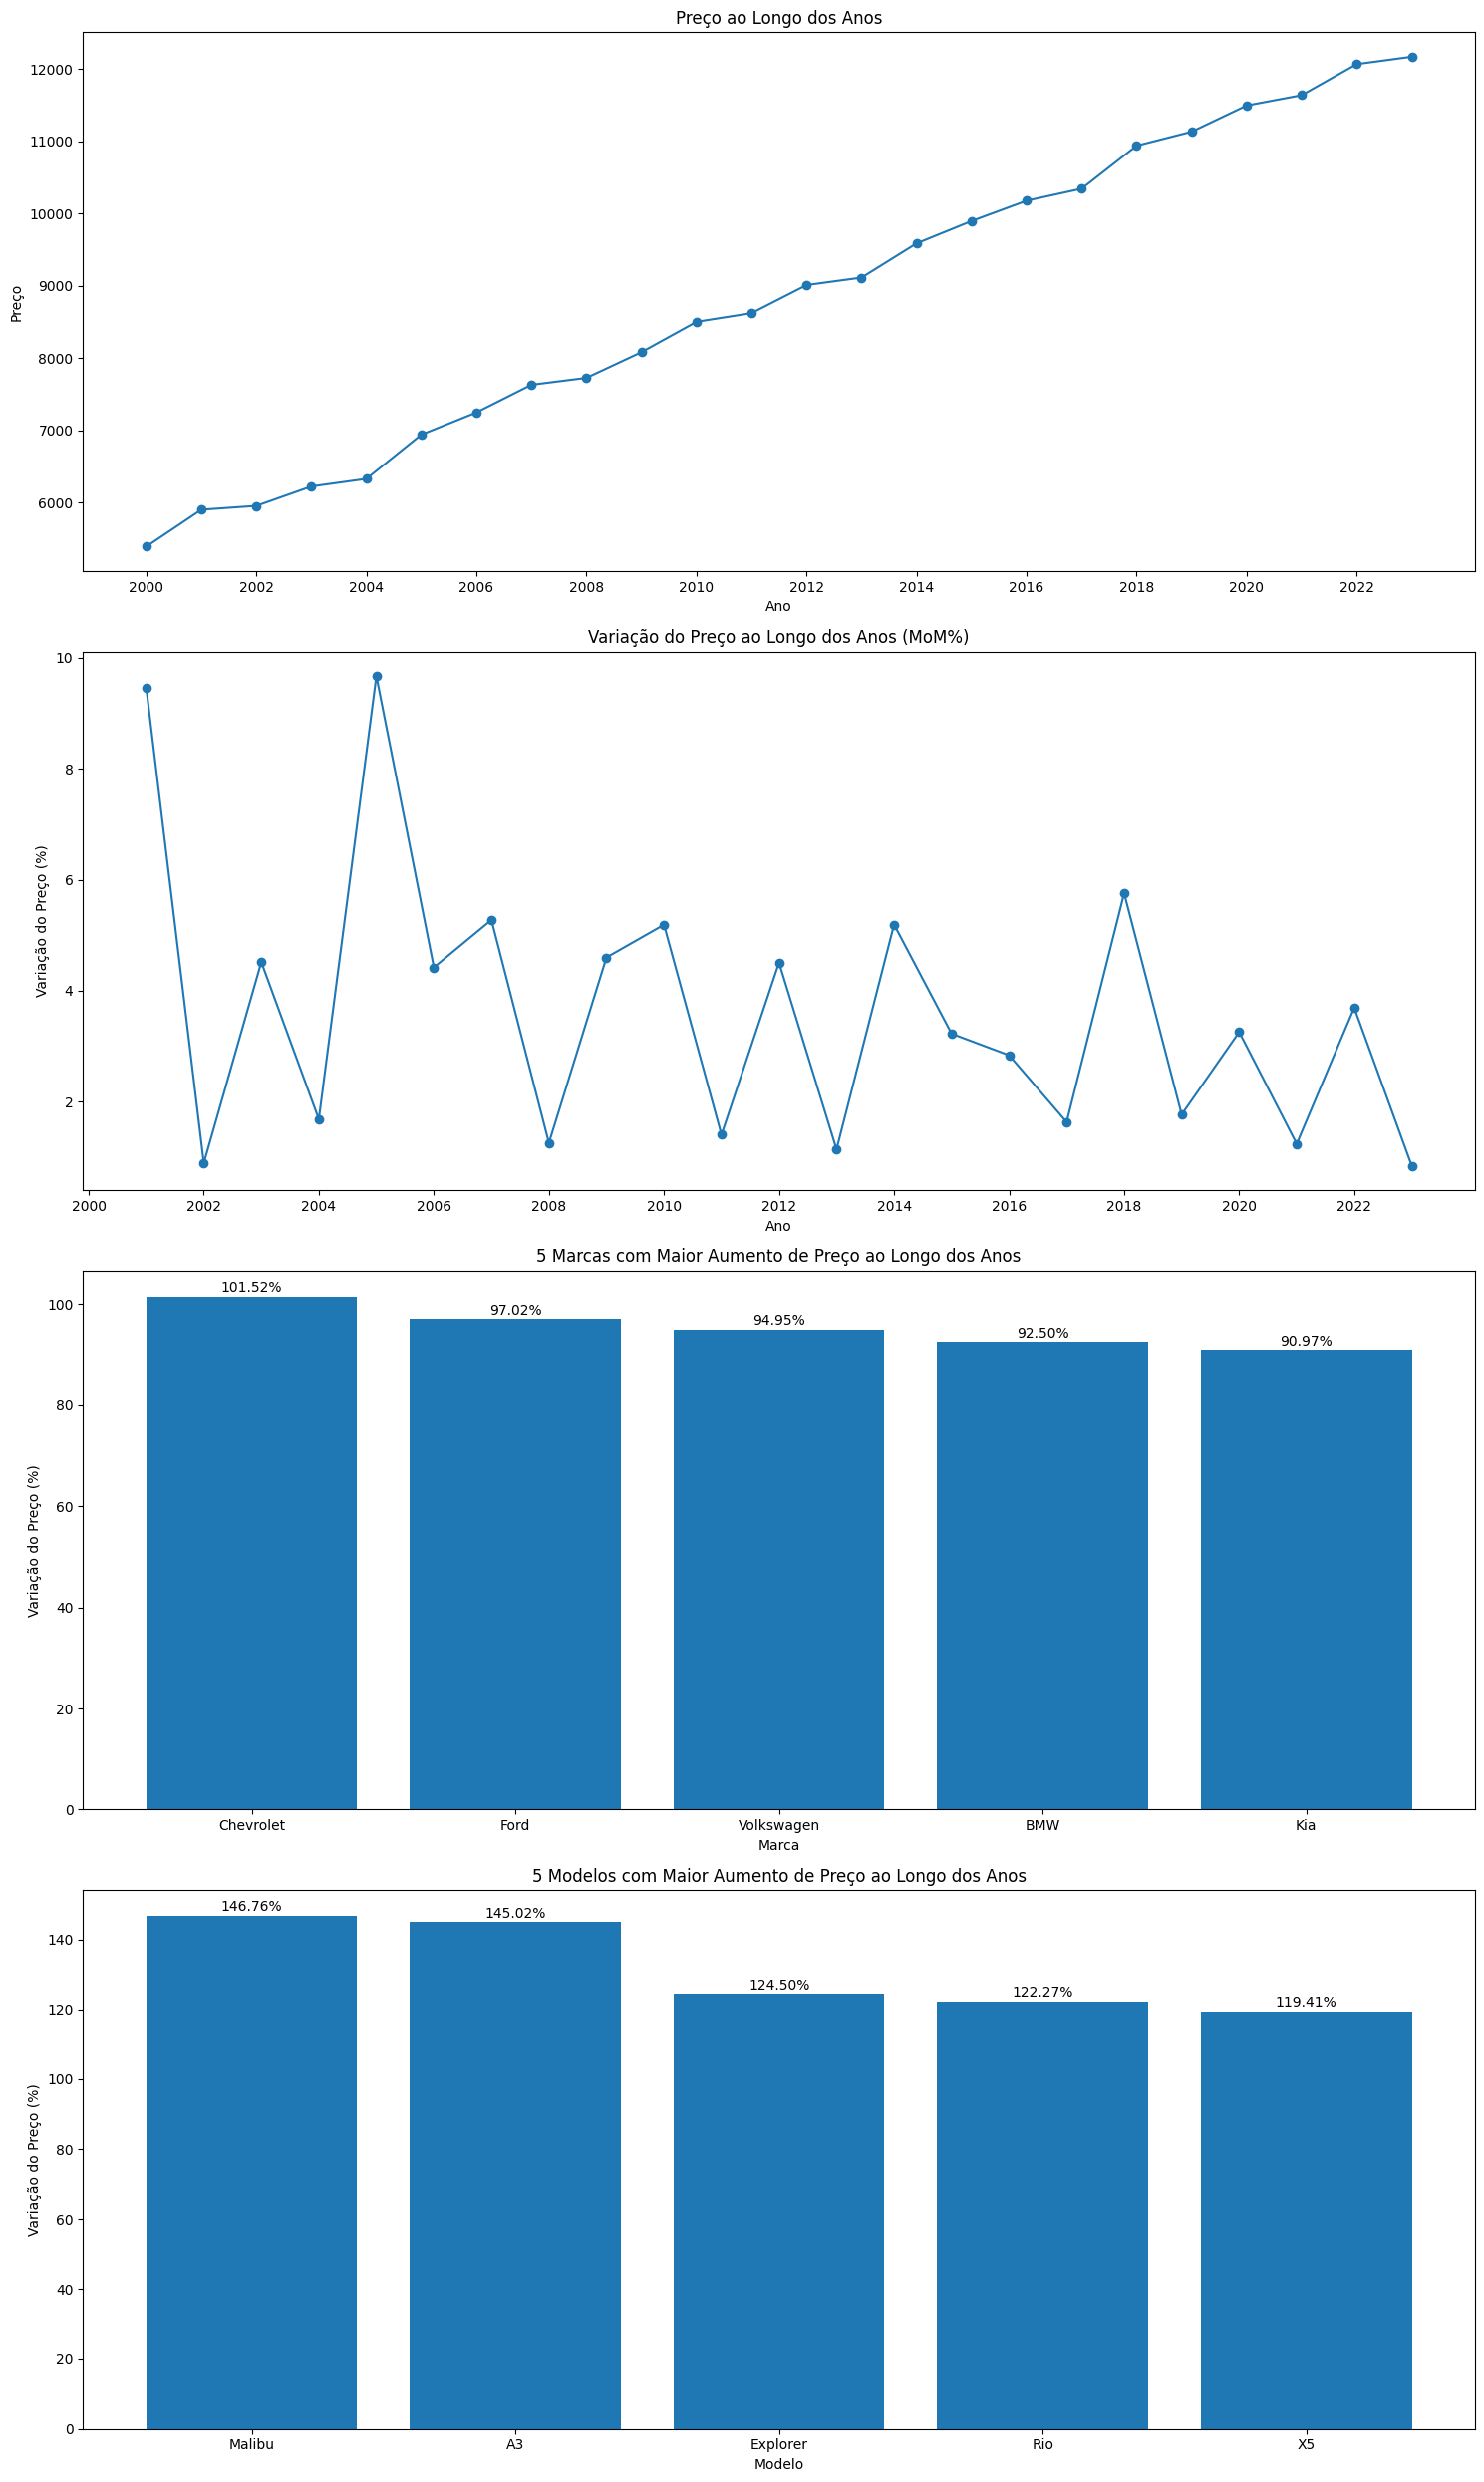

In [ ]:
fig, axes = plt.subplots(4,1,figsize=(15, 25))

ax = axes[0]

ax.plot(df_anos_precos['Year'], df_anos_precos['Price'], marker='o', linestyle='-')
ax.set_xticks(df_anos_precos['Year'][::2])
ax.set_xlabel('Ano')
ax.set_ylabel('Preço')
ax.set_title('Preço ao Longo dos Anos')

ax = axes[1]

ax.plot(df_anos_precos['Year'], df_anos_precos['MoM%'], marker='o', linestyle='-')
ax.set_xticks(df_anos_precos['Year'][::2])
ax.set_xlabel('Ano')
ax.set_ylabel('Variação do Preço (%)')
ax.set_title('Variação do Preço ao Longo dos Anos (MoM%)')

ax = axes[2]

barras = ax.bar(df_top_5_marcas['Brand'], df_top_5_marcas['MoM%'])
ax.bar_label(barras, fmt='%.2f%%', padding=1, label_type='edge')
ax.set_xlabel('Marca')
ax.set_ylabel('Variação do Preço (%)')
ax.set_title('5 Marcas com Maior Aumento de Preço ao Longo dos Anos')

ax = axes[3]

barras = ax.bar(df_top_5_modelo['Model'], df_top_5_modelo['MoM%'])
ax.bar_label(barras, fmt='%.2f%%', padding=1, label_type='edge')
ax.set_xlabel('Modelo')
ax.set_ylabel('Variação do Preço (%)')
ax.set_title('5 Modelos com Maior Aumento de Preço ao Longo dos Anos')

plt.tight_layout()
plt.show()

In [ ]:
#@markdown #### .

classe = [2000,2003,2006,2009,2012,2015,2018,2021,2023]

labels = [
    '2000 - 2003',
    '2003 - 2006',
    '2006 - 2009',
    '2009 - 2012',
    '2012 - 2015',
    '2015 - 2018',
    '2018 - 2021',
    '2021 - 2023'
]

dados_copia = dados.copy()

dados_copia['Faixa_Ano'] = pd.cut(x=dados.Year,bins=classe,labels=labels,include_lowest=True)
df_media_preco_faixa_ano = dados_copia.groupby(['Faixa_Ano'], observed=True)['Price'].mean().reset_index()

df_marcas_media_preco = dados_copia.groupby('Brand', observed=True)['Price'].mean().reset_index()
df_marcas_media_preco = df_marcas_media_preco.sort_values(by='Price', ascending=False)

df_media_preco_faixa_ano_marca = dados_copia.groupby(['Faixa_Ano','Brand'], observed=True)['Price'].mean().reset_index()
df_top_marcas_caros = df_media_preco_faixa_ano_marca.loc[df_media_preco_faixa_ano_marca.groupby('Faixa_Ano', observed=True)['Price'].idxmax()].reset_index(drop=True)
df_top_marcas_baratos = df_media_preco_faixa_ano_marca.loc[df_media_preco_faixa_ano_marca.groupby('Faixa_Ano', observed=True)['Price'].idxmin()].reset_index(drop=True)

df_top_marcas_caros = df_top_marcas_caros.rename(columns={'Price': 'Preco Medio caro',
                                              'Brand': 'Marca mais Cara por Faixa',
                                              'Faixa_Ano': 'Faixa de Ano'})
df_top_marcas_baratos = df_top_marcas_baratos.rename(columns={'Price': 'Preco Medio barato',
                                              'Brand': 'Marca mais Barata por Faixa',
                                              'Faixa_Ano': 'Faixa de Ano'})

df_top_marcas_caros['Preco Medio caro'] = df_top_marcas_caros['Preco Medio caro'].round(2)
df_top_marcas_baratos['Preco Medio barato'] = df_top_marcas_baratos['Preco Medio barato'].round(2)

df_top_marcas = pd.merge(df_top_marcas_baratos, df_top_marcas_caros, on='Faixa de Ano')

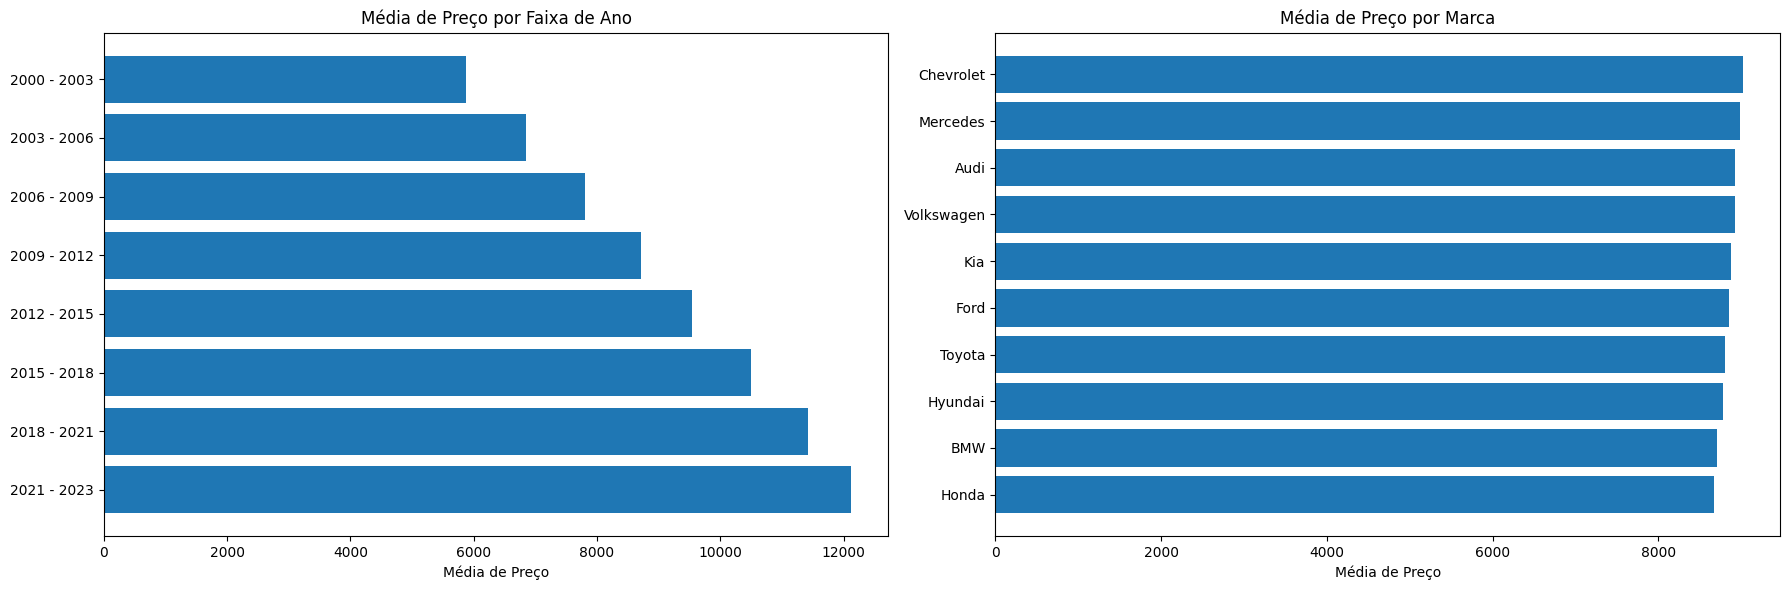

,Faixa de Ano,Marca mais Barata por Faixa,Preco Medio barato,Marca mais Cara por Faixa,Preco Medio caro
0,2000 - 2003,Ford,5761.05,Mercedes,6033.34
1,2003 - 2006,Toyota,6536.00,Kia,7114.29
2,2006 - 2009,Honda,7479.51,Kia,8034.64
3,2009 - 2012,Hyundai,8493.16,Chevrolet,9078.66
4,2012 - 2015,Toyota,9197.64,Audi,9856.92
5,2015 - 2018,Hyundai,10211.15,Audi,10818.14
6,2018 - 2021,Chevrolet,11146.05,Mercedes,11778.31
7,2021 - 2023,Audi,11605.16,Chevrolet,12379.90


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]

ax.barh(df_media_preco_faixa_ano['Faixa_Ano'], df_media_preco_faixa_ano['Price'])
ax.set_xlabel('Média de Preço')
ax.set_title('Média de Preço por Faixa de Ano')
ax.invert_yaxis()

ax = axes[1]

ax.barh(df_marcas_media_preco['Brand'], df_marcas_media_preco['Price'])
ax.set_xlabel('Média de Preço')
ax.set_title('Média de Preço por Marca')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

df_top_marcas

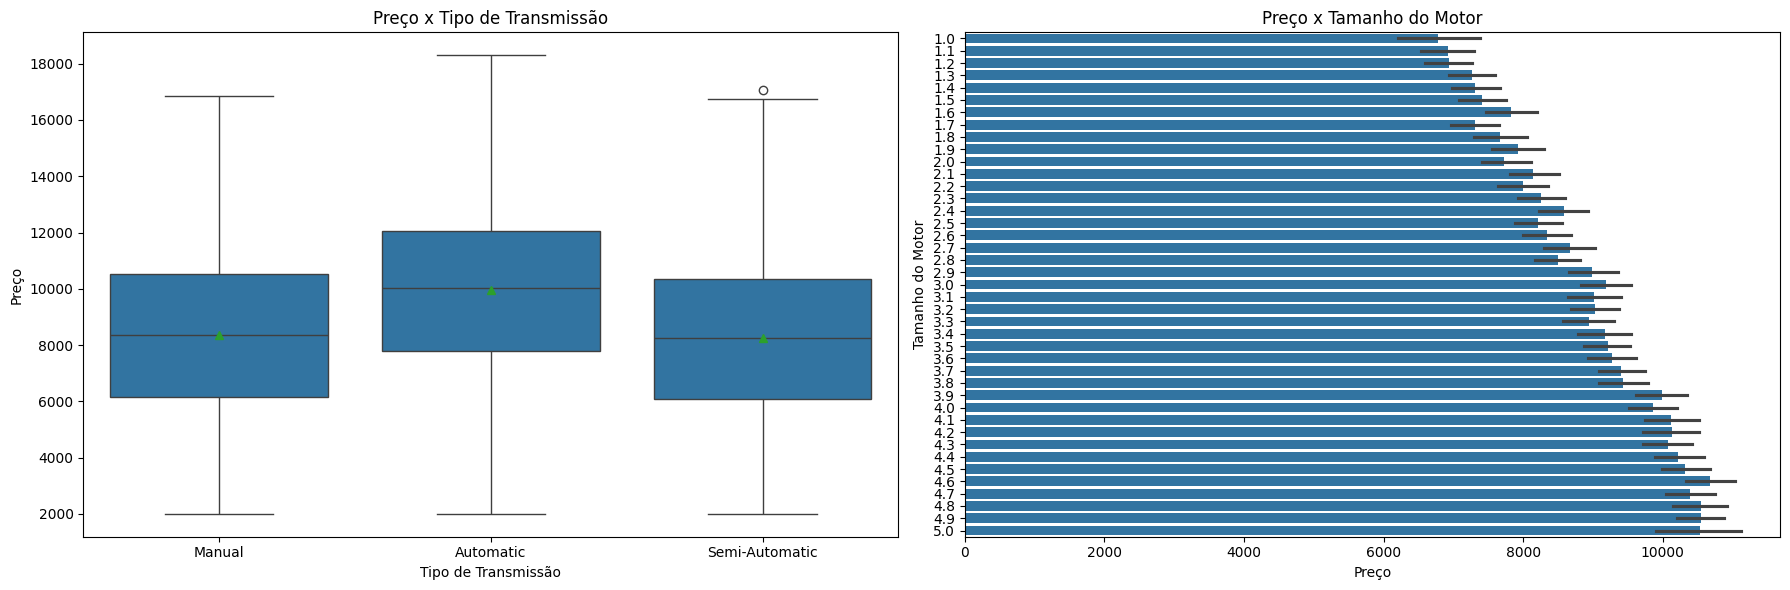

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]

ax = sns.boxplot(x='Transmission', y='Price', data=dados, ax=ax, showmeans=True)
ax.set_xlabel('Tipo de Transmissão')
ax.set_ylabel('Preço')
ax.set_title('Preço x Tipo de Transmissão')

ax = axes[1]

ax = sns.barplot(y='Engine_Size', x='Price', data=dados, ax=ax, orient='h', estimator="mean")
ax.set_xlabel('Preço')
ax.set_ylabel('Tamanho do Motor')
ax.set_title('Preço x Tamanho do Motor')

plt.tight_layout()
plt.show()


In [ ]:
#@markdown #### .
classes = [0,50000,100000,150000,200000,250000,300000]

labes = [
    '0 - 50k',
    '50k - 100k',
    '100k - 150k',
    '150k - 200k',
    '200k - 250k',
    '250k - 300k'
]

dados_copia['Faixa_Quilometragem'] = pd.cut(x=dados['Mileage'],bins=classes,labels=labes,include_lowest=True)
df_media_preco_faixa_km = dados_copia.groupby(['Faixa_Quilometragem'], observed=True)['Price'].mean().reset_index()

df_media_preco_modelos = dados_copia.groupby(['Model'], observed=True)['Price'].mean().reset_index()
df_media_preco_modelos = df_media_preco_modelos.sort_values(by='Price', ascending=False)

df_top_10_modelos = df_media_preco_modelos.nlargest(10, 'Price')

df_media_preco_km_modelo = dados_copia.groupby(['Faixa_Quilometragem','Model'], observed=True)['Price'].mean().reset_index()
df_top_modelos_caros = df_media_preco_km_modelo.loc[df_media_preco_km_modelo.groupby('Faixa_Quilometragem', observed=True)['Price'].idxmax()].reset_index(drop=True)
df_top_modelos_baratos = df_media_preco_km_modelo.loc[df_media_preco_km_modelo.groupby('Faixa_Quilometragem', observed=True)['Price'].idxmin()].reset_index(drop=True)
df_top_modelos_caros = df_top_modelos_caros.rename(columns={'Price': 'Preco Medio caros',
                                                'Model': 'Modelo mais Caro por Faixa',
                                                'Faixa_Quilometragem': 'Faixa de Quilometragem'})
df_top_modelos_baratos = df_top_modelos_baratos.rename(columns={'Price': 'Preco Medio baratos',
                                                'Model': 'Modelo mais Barato por Faixa',
                                                'Faixa_Quilometragem': 'Faixa de Quilometragem'})

df_top_modelos_caros['Preco Medio caros'] = df_top_modelos_caros['Preco Medio caros'].round(2)
df_top_modelos_baratos ['Preco Medio baratos'] = df_top_modelos_baratos ['Preco Medio baratos'].round(2)

df_top_modelos = pd.merge(df_top_modelos_baratos, df_top_modelos_caros, on='Faixa de Quilometragem')


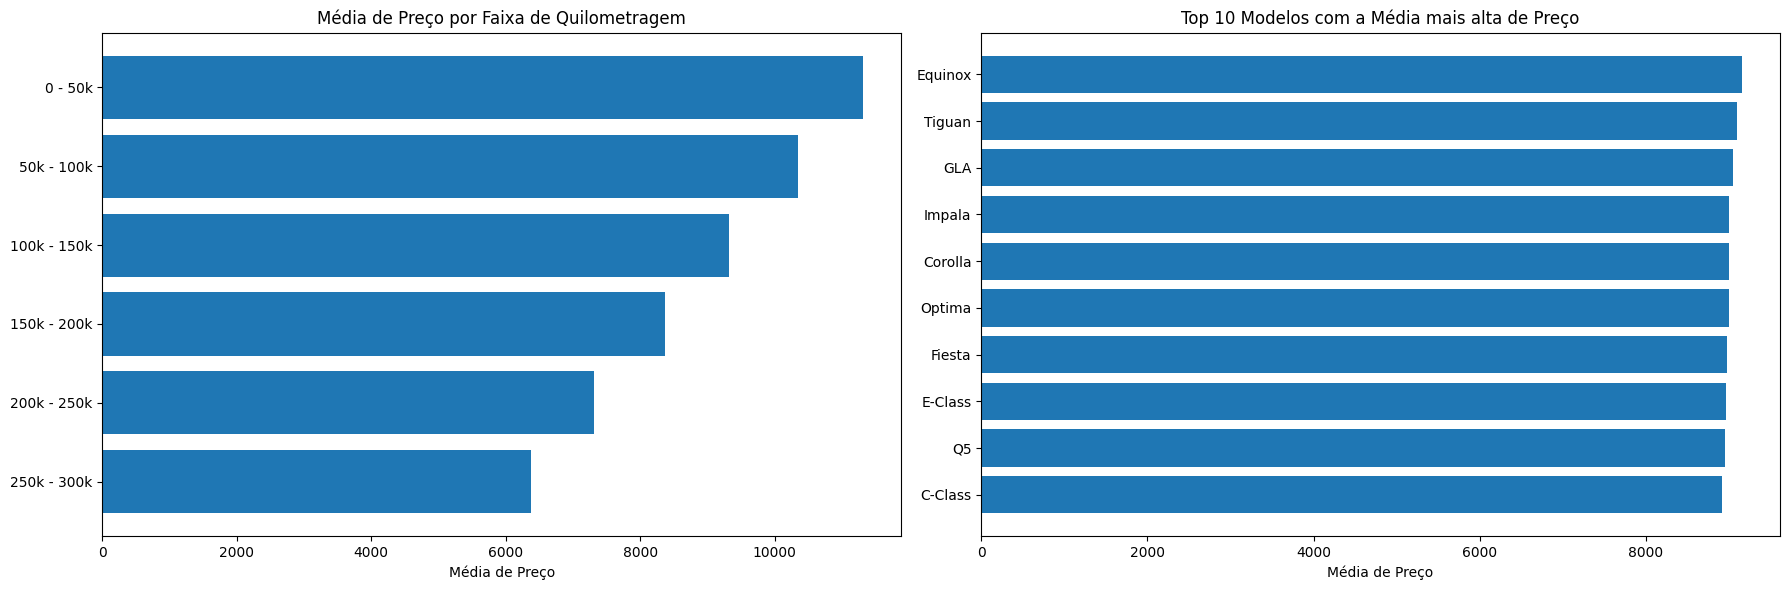

,Faixa de Quilometragem,Modelo mais Barato por Faixa,Preco Medio baratos,Modelo mais Caro por Faixa,Preco Medio caros
0,0 - 50k,3 Series,10762.09,C-Class,12030.41
1,50k - 100k,Accord,9468.69,Sportage,11167.66
2,100k - 150k,Explorer,8679.78,Civic,10042.22
3,150k - 200k,Corolla,7857.02,GLA,9367.17
4,200k - 250k,Impala,6794.83,Fiesta,7926.45
5,250k - 300k,GLA,5402.59,Tiguan,7060.00


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]

ax.barh(df_media_preco_faixa_km['Faixa_Quilometragem'], df_media_preco_faixa_km['Price'])
ax.set_xlabel('Média de Preço')
ax.set_title('Média de Preço por Faixa de Quilometragem')
ax.invert_yaxis()

ax = axes[1]

ax.barh(df_top_10_modelos['Model'], df_top_10_modelos['Price'])
ax.set_xlabel('Média de Preço')
ax.set_title('Top 10 Modelos com a Média mais alta de Preço')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

df_top_modelos

In [ ]:
#@markdown #### .
df_media_precos_x_prop = dados.groupby(['Owner_Count'])['Price'].mean().reset_index()
df_media_precos_x_prop = df_media_precos_x_prop.sort_values(by='Owner_Count', ascending=True)
df_media_precos_x_prop['Owner_Count'] = df_media_precos_x_prop['Owner_Count'].astype(str)

df_media_precos_x_fuel = dados.groupby(['Fuel_Type'])['Price'].mean().reset_index()
df_media_precos_x_fuel = df_media_precos_x_fuel.sort_values(by='Price', ascending=False)
df_media_precos_x_fuel['Fuel_Type'] = df_media_precos_x_fuel['Fuel_Type'].astype(str)

df_pro_x_fuel = dados.groupby('Fuel_Type')['Owner_Count'].sum().reset_index()
df_pro_x_fuel['Owner_Count'] = df_pro_x_fuel['Owner_Count'].round().astype(int)
df_pro_x_fuel = df_pro_x_fuel.sort_values(by='Owner_Count', ascending=False)
df_pro_x_fuel['Owner_Count %'] = (df_pro_x_fuel['Owner_Count'] / df_pro_x_fuel['Owner_Count'].sum() * 100).round(2)

df_media_precos_x_prop_x_fuel = dados.groupby(['Fuel_Type','Owner_Count'])['Price'].mean().reset_index()

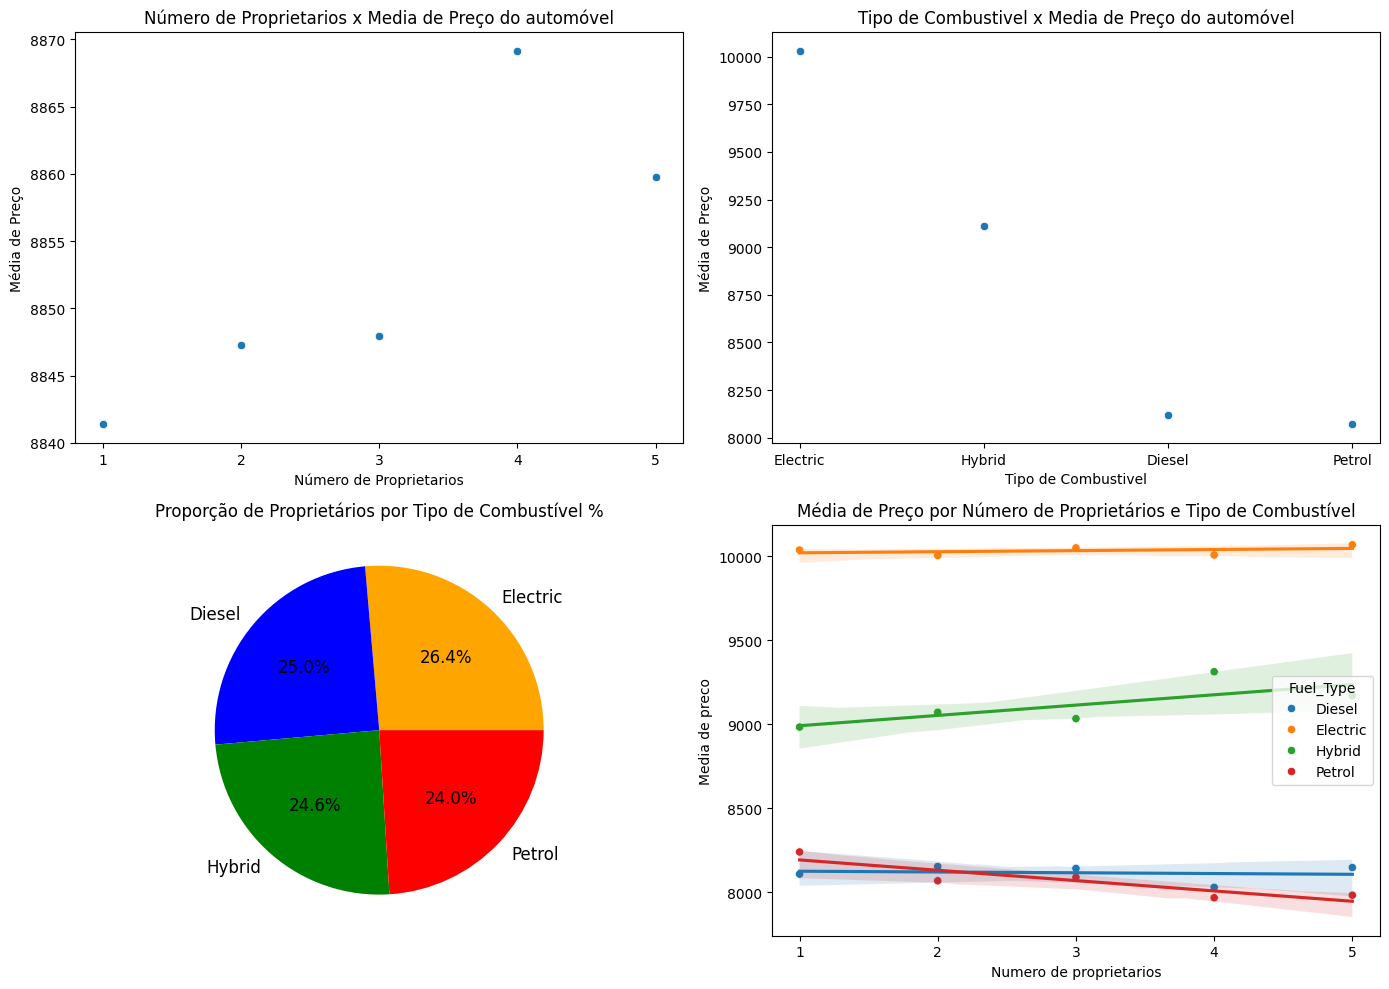

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


ax = axes[0,0]

ax = sns.scatterplot(x='Owner_Count',y='Price', data=df_media_precos_x_prop,  ax=ax)
ax.set_xlabel('Número de Proprietarios')
ax.set_ylabel('Média de Preço')
ax.set_title('Número de Proprietarios x Media de Preço do automóvel')


ax = axes[0,1]

ax = sns.scatterplot(x='Fuel_Type',y='Price', data=df_media_precos_x_fuel, ax=ax)
ax.set_xlabel('Tipo de Combustivel')
ax.set_ylabel('Média de Preço')
ax.set_title('Tipo de Combustivel x Media de Preço do automóvel')


ax = axes[1,0]

ax.pie(df_pro_x_fuel['Owner_Count'], labels=df_pro_x_fuel['Fuel_Type'], autopct='%1.1f%%', colors=['orange','blue','green','red'], textprops={'color':'black','fontsize':12})
ax.set_title('Proporção de Proprietários por Tipo de Combustível %')

ax = axes[1,1]

ax = sns.scatterplot(x='Owner_Count', y='Price', hue='Fuel_Type', data=df_media_precos_x_prop_x_fuel, ax=ax)

for fuel in df_media_precos_x_prop_x_fuel["Fuel_Type"].unique():
  sns.regplot(x="Owner_Count", y="Price", data=df_media_precos_x_prop_x_fuel[df_media_precos_x_prop_x_fuel["Fuel_Type"] == fuel], scatter=False, label=fuel)

ax.set_xlabel('Numero de proprietarios')
ax.set_xticks(range(1,df_media_precos_x_prop_x_fuel['Owner_Count'].max() +1))
ax.set_ylabel('Media de preco')
ax.set_title('Média de Preço por Número de Proprietários e Tipo de Combustível')

plt.tight_layout()
plt.show()

In [ ]:
#Transformando as variaveis Categoricas em Numericas
label_encoder = LabelEncoder()
for coluna in ['Brand','Model','Transmission','Fuel_Type']:
    dados[coluna] = label_encoder.fit_transform(dados[coluna])

In [ ]:
correlacao = dados.corr()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
Brand,1.000000,0.313190,-0.000860,0.001273,-0.005946,0.009454,-0.010180,-0.000619,0.019997,0.003490
Model,0.313190,1.000000,-0.011853,0.003442,0.004802,-0.010309,-0.007543,0.014199,0.024990,0.002996
Year,-0.000860,-0.011853,1.000000,-0.001306,-0.009079,-0.009719,-0.002476,0.014867,0.000116,0.663036
Engine_Size,0.001273,0.003442,-0.001306,1.000000,-0.001893,-0.009950,0.015135,-0.009844,0.007122,0.357403
Fuel_Type,-0.005946,0.004802,-0.009079,-0.001893,1.000000,0.001864,-0.008635,0.011704,-0.000736,-0.037178
Transmission,0.009454,-0.010309,-0.009719,-0.009950,0.001864,1.000000,0.020790,0.002211,-0.000954,-0.218992
Mileage,-0.010180,-0.007543,-0.002476,0.015135,-0.008635,0.020790,1.000000,0.007879,0.006287,-0.551227
Doors,-0.000619,0.014199,0.014867,-0.009844,0.011704,0.002211,0.007879,1.000000,-0.005431,0.000511
Owner_Count,0.019997,0.024990,0.000116,0.007122,-0.000736,-0.000954,0.006287,-0.005431,1.000000,0.002656
Price,0.003490,0.002996,0.663036,0.357403,-0.037178,-0.218992,-0.551227,0.000511,0.002656,1.000000


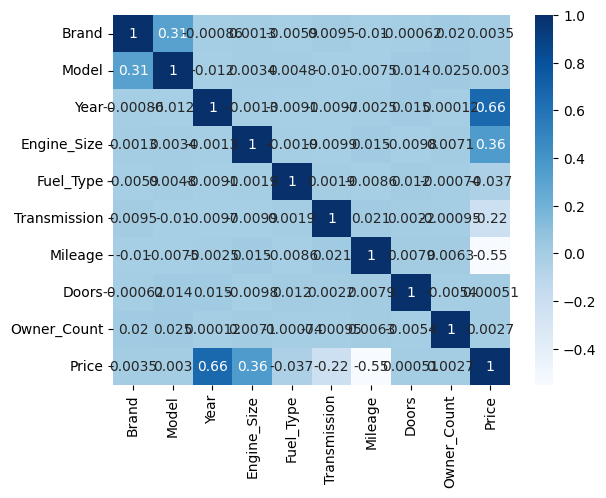

In [ ]:
sns.heatmap(correlacao,annot=True,cmap='Blues')
correlacao

## Preparação dos dados para modelagem

In [ ]:
#@markdown #### .
def _aic(n,mse,k):
  return n * np.log(mse) + 2 * k

In [ ]:
#Separando os atributos (X) da variavel preditora (y)
X = dados.drop('Price', axis=1)
y = dados['Price']

In [ ]:
#Dividindo os dados para treino e teste (Teste 20% Treino 80%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Valor "alpha" para regularização. Para ser usado nos Modelos Rigde e Lasso
alphas = np.logspace(-6, 6, 13)

## Treinamento dos modelos preditivos



---
**Modelo Ridge**


In [ ]:
#Treinar o modelo usando Ridge
ridge = Ridge()
#Metodo de validação cruzada para encontrar o melhor valor alpha
modelo_ridge_teste = GridSearchCV(ridge, {'alpha': alphas}, cv=5, scoring='neg_mean_squared_error')
modelo_ridge_teste.fit(X_train, y_train)
#Predição do modelo
predicao_modelo_ridge = modelo_ridge_teste.predict(X_test)
#Estatisticas que representam o desempenho do modelo
ridge_R2 = r2_score(y_test, predicao_modelo_ridge)
ridge_MSE = mean_squared_error(y_test, predicao_modelo_ridge)
n = len(y_test)
k = len(X_train.columns)+1
ridge_aic = _aic(n,ridge_MSE,k)


In [ ]:
#Visualização dos atributos mais importantes para o modelo.
importancia = modelo_ridge_teste.best_estimator_.coef_
atributos = sorted(list(zip(X.columns,importancia)), key=lambda x: x[1], reverse=True)
for coluna, valor in atributos:
    print(f"{coluna}: {valor.round(3)}")



Engine_Size: 991.158
Year: 297.946
Model: 1.741
Owner_Count: 1.505
Mileage: -0.02
Brand: -0.344
Doors: -1.783
Fuel_Type: -98.212
Transmission: -772.788


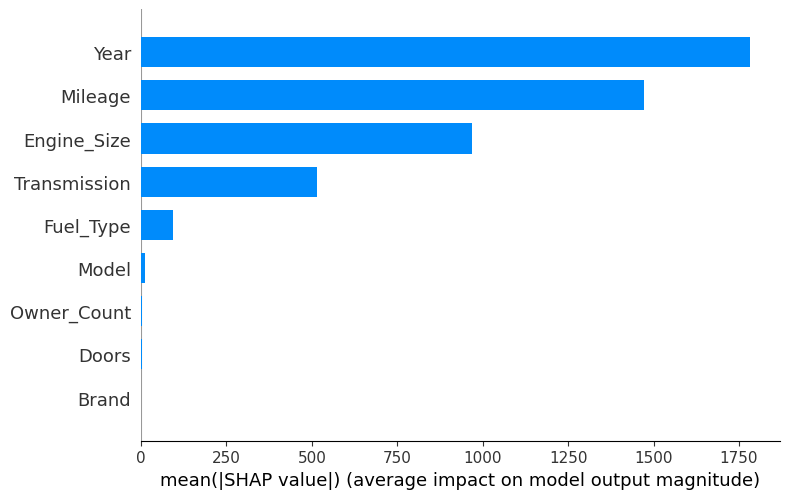

In [ ]:
#SHAP é um metodo para visualizar os atributos, levando em consideração seus relacionamentos entre si, que mais contribuem para a variavel preditora
expln = shap.LinearExplainer(modelo_ridge_teste.best_estimator_, X_train)
shap_values = expln.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")



---

**Modelo Lasso**

In [ ]:
#Treinar o modelo usando Lasso
lasso = Lasso()
#Metodo de validação cruzada para encontrar o melhor valor alpha
modelo_lasso = GridSearchCV(lasso, {'alpha': alphas}, cv=5, scoring='neg_mean_squared_error')
#"Treinando" o modelo
modelo_lasso.fit(X_train, y_train)
#Predição do modelo
predicao_modelo_lasso = modelo_lasso.predict(X_test)
#Estatisticas que representam o desempenho do modelo
lasso_R2 = r2_score(y_test, predicao_modelo_lasso)
lasso_MSE = mean_squared_error(y_test, predicao_modelo_lasso)
n = len(y_test)
k = len(X_train.columns)+1
lasso_aic = _aic(n,lasso_MSE,k)

In [ ]:
#Visualização dos atributos mais importantes para o modelo.
importancia = modelo_lasso.best_estimator_.coef_
atributos = sorted(list(zip(X.columns,importancia)), key=lambda x: x[1], reverse=True)
for coluna, valor in atributos:
    print(f"{coluna}: {valor.round(3)}")


Engine_Size: 983.885
Year: 297.765
Model: 1.578
Brand: -0.0
Doors: -0.0
Owner_Count: 0.0
Mileage: -0.02
Fuel_Type: -90.188
Transmission: -757.964




---
**Modelo Regressão Linear**


In [ ]:
#No primeiro modelo RIDGE, se baseando nas variaveis que mais contribuem para a variavel preditora, foi criado o modelo de Regressão Linear
X = dados[['Engine_Size','Year','Transmission','Mileage','Fuel_Type']]
y = dados['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [ ]:
#"Treinando" o modelo
modelo_ols = sm.OLS(y_train, X_train).fit()
#Predição do modelo
predicao_modelo_ols = modelo_ols.predict(X_test)

#Estatisticas que representam o desempenho do modelo
ols_R2 = modelo_ols.rsquared
ols_MSE = mean_squared_error(y_test, predicao_modelo_ols)
n = len(y_test)
k = len(X_train.columns)+1
ols_aic = _aic(n,ols_MSE,k)
print(modelo_ols.summary())

## Visualização dos desempenhos dos modelos

In [ ]:
print("R2 Ridge:", ridge_R2)
print("MSE Ridge:", ridge_MSE)
print("AIC Ridge: ", ridge_aic)

R2 Ridge: 0.9109052278612643
MSE Ridge: 818586.0031151958
AIC Ridge:  27250.667488659747


In [ ]:
print("R2 Lasso:", lasso_R2)
print("MSE Lasso:", lasso_MSE)
print("AIC Lasso: ", lasso_aic)

R2 Lasso: 0.9110992389818114
MSE Lasso: 816803.4654430489
AIC Lasso:  27246.307577061114


In [ ]:
print("R2 OLS:", ols_R2)
print("MSE OLS:", ols_MSE)
print("AIC OLS: ", ols_aic)

R2 OLS: 0.9174645243136094
MSE OLS: 818443.1622026811
AIC OLS:  27244.318463936415


**Conclusão**

O Modelo de Regressão Linear (OLS) é que mostra que tem o melhor desempenho: R2 (Modelo que melhor explica os dados) mais alto e o AIC menor (Modelo mais efeciente)